In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
print("Entorno listo ✅")

Entorno listo ✅


**Carga del DATASET**

In [ ]:
# cargar datos necesarios para la elaboración de la predicción del modelo
path = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/bank.csv'
df = pd.read_csv(path, sep="," )

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


 1. Introducción

**El problema de negocio.** ABC Multistate Bank está perdiendo clientes: cada vez más personas cierran sus cuentas. Esto duele por dos lados: se pierden los ingresos que generaba ese cliente y, además, captar un cliente nuevo cuesta bastante más que retener a uno existente (marketing, promociones, onboarding).

**Por qué predecir el churn aporta valor.** Si el banco logra identificar *con anticipación* qué clientes están a punto de irse, puede intervenir a tiempo —con una oferta, una llamada, un beneficio— en lugar de enterarse cuando ya cerraron la cuenta. Es la diferencia entre **prevenir** y **lamentar**.

**Objetivo del proyecto.** Construir un modelo de clasificación que, a partir de los datos del cliente (edad, país, productos, actividad, saldo, etc.), estime la probabilidad de que abandone el banco. Compararemos cuatro modelos, elegiremos el mejor según **ROC-AUC**, ajustaremos el umbral de decisión a las necesidades del negocio y traduciremos los resultados en recomendaciones concretas de retención.

**2. ANALISIS EXPLORATORIO DE DATOS (EDA)**

Antes de modelar necesitamos *entender* los datos: su estructura, su calidad y cómo se relaciona cada variable con el churn. Un buen EDA es lo que después justifica todas las decisiones de preprocesamiento.

**2.1 DESCRIPCIÓN GENERAL**

In [ ]:
print("Dimensiones:", df.shape)
print("\n--- Tipos de datos e info ---")
df.info()
print("\n--- Duplicados (filas completas):", df.duplicated().sum())
print("--- Duplicados de customer_id:", df['customer_id'].duplicated().sum())
print("\n--- Valores faltantes por columna ---")
print(df.isnull().sum())

Dimensiones: (10000, 12)

--- Tipos de datos e info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB

--- Duplicados (filas completas): 0
--- Duplicados de customer_id: 0

--- Valores faltantes por columna ---
custo

In [ ]:
# Estadísticos descriptivos de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


> **Conclusión 2.1.** El dataset está **muy limpio**: 10.000 filas, **sin valores faltantes y sin duplicados** (ni de filas ni de `customer_id`). Esto simplifica el preprocesamiento: no necesitaremos imputar datos. La columna `customer_id` es solo un identificador y **no aporta información predictiva**, así que la eliminaremos antes de modelar.

**2.2 ANALISIS UNIVARIADO**

Veamos primero la variable objetivo (¿está balanceada?) y luego las distribuciones de las variables numéricas y categóricas.

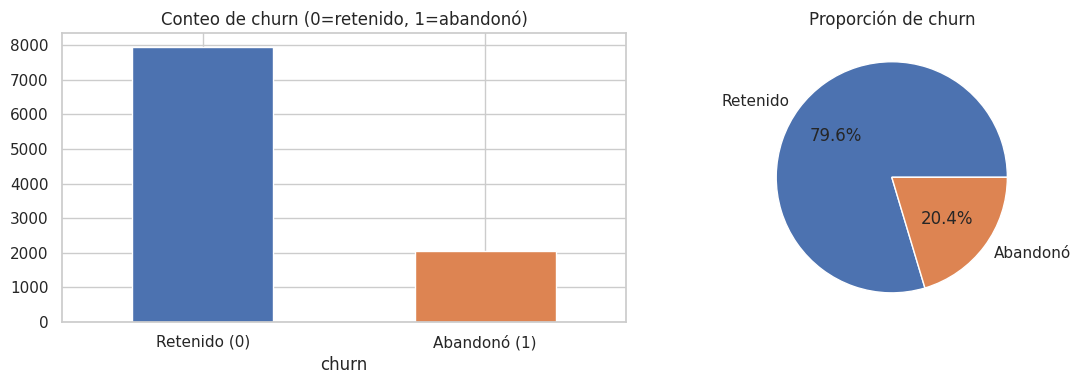

churn
0    79.63
1    20.37
Name: proportion, dtype: float64


In [ ]:
# Distribución de la variable objetivo
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['churn'].value_counts().plot(kind='bar', ax=ax[0], color=['#4C72B0', '#DD8452'])
ax[0].set_title('Conteo de churn (0=retenido, 1=abandonó)')
ax[0].set_xticklabels(['Retenido (0)', 'Abandonó (1)'], rotation=0)

df['churn'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%',
        labels=['Retenido', 'Abandonó'], ax=ax[1], colors=['#4C72B0', '#DD8452'])
ax[1].set_ylabel('')
ax[1].set_title('Proporción de churn')
plt.tight_layout(); plt.show()

print(df['churn'].value_counts(normalize=True).round(4) * 100)

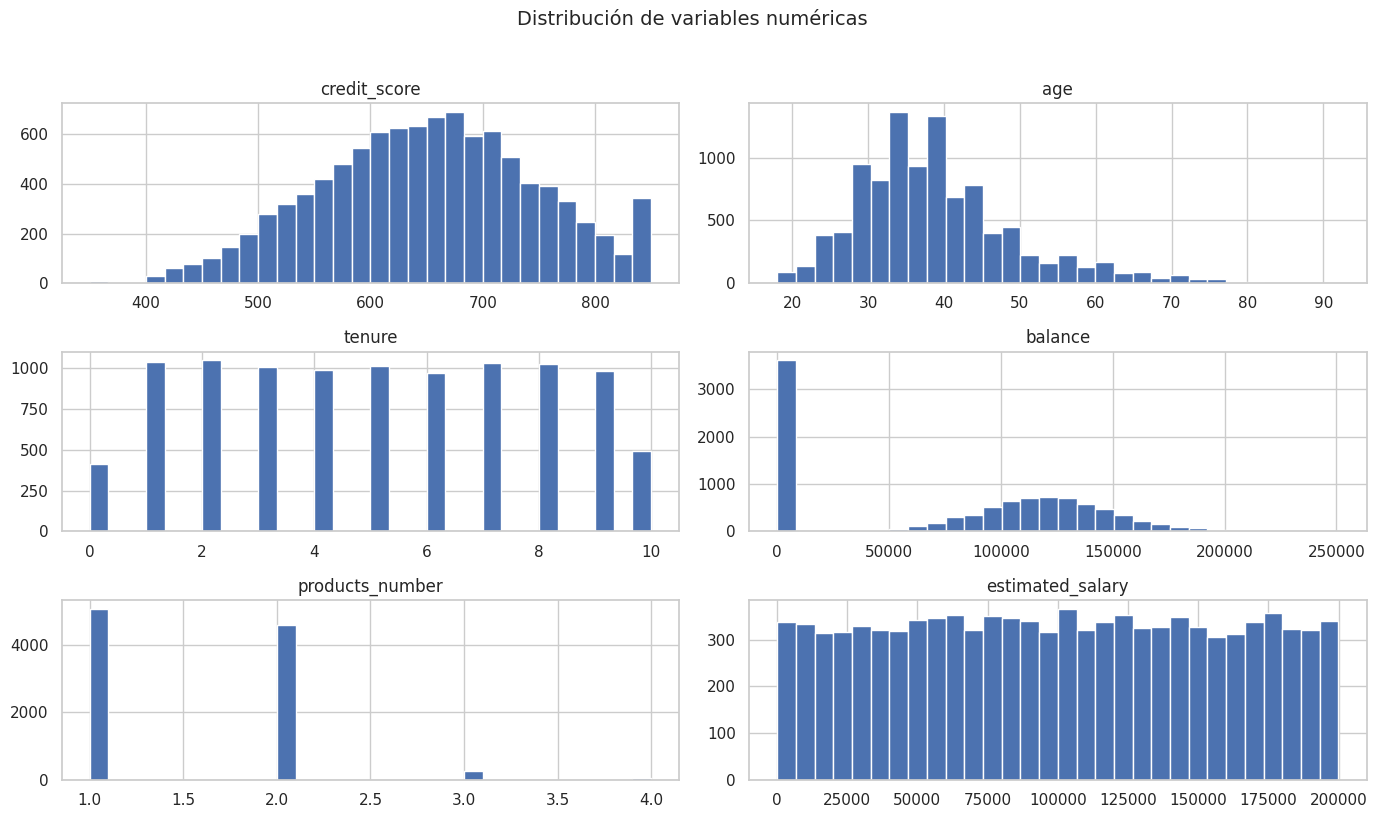

In [ ]:
# Distribuciones de variables numéricas
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
df[num_cols].hist(figsize=(14, 8), bins=30, color='#4C72B0', edgecolor='white')
plt.suptitle('Distribución de variables numéricas', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

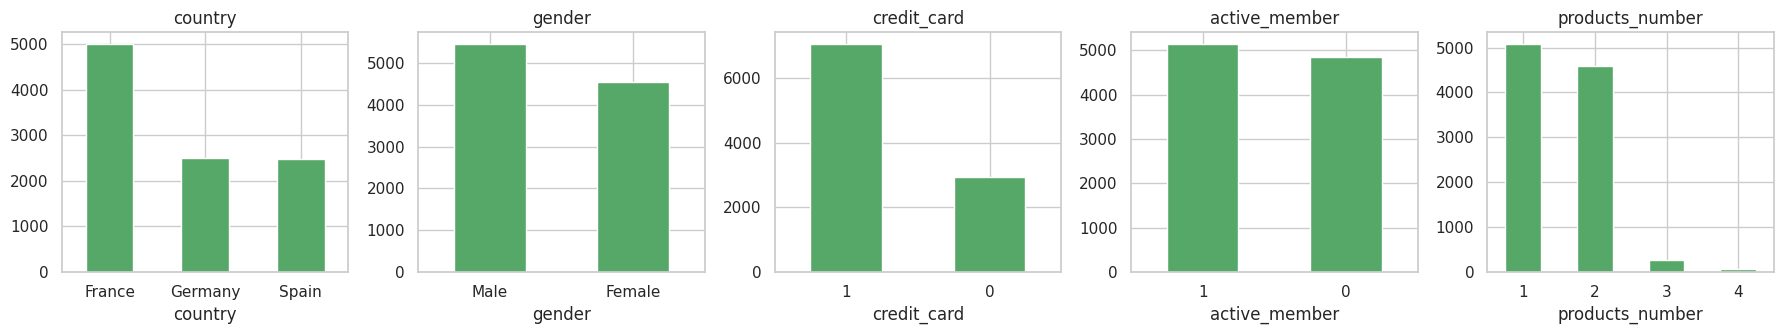

In [ ]:
# Proporciones de variables categóricas / binarias
cat_cols = ['country', 'gender', 'credit_card', 'active_member', 'products_number']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 3.5))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='#55A868')
    ax.set_title(col); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

> **Conclusión 2.2.**
> - **Clases desbalanceadas:** solo **~20,4%** de los clientes abandonan vs ~79,6% que se quedan (relación ≈ 1:4). Esto es clave: tendremos que abordar el desbalance y **no** confiar en la *accuracy* como métrica.
> - `age` está sesgada a la derecha (cola de clientes mayores). `balance` es bimodal: un grupo grande con saldo **0** y el resto repartido alrededor de ~100k. `credit_score` y `estimated_salary` se ven bastante simétricas.
> - La mayoría de clientes tiene **1 o 2 productos**; tener 3 o 4 es raro. Los grupos están razonablemente repartidos por país y género.

**2.3 ANALISIS BIVARIADO**

Ahora lo importante: ¿cómo se relaciona cada predictor con el churn?

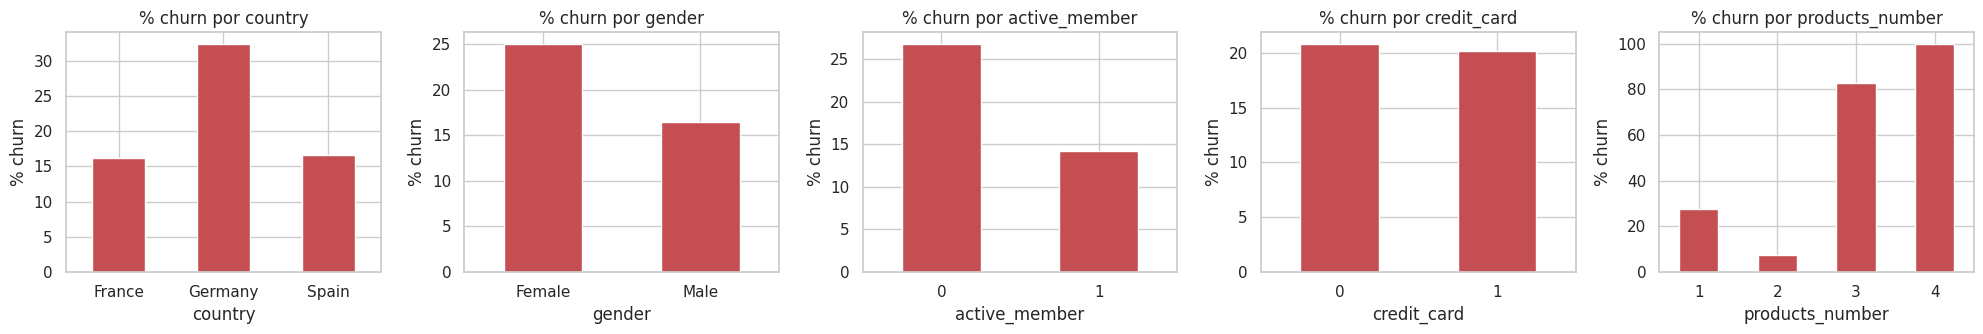


% churn por country:
country
France     16.15
Germany    32.44
Spain      16.67
Name: churn, dtype: float64

% churn por gender:
gender
Female    25.07
Male      16.46
Name: churn, dtype: float64

% churn por active_member:
active_member
0    26.85
1    14.27
Name: churn, dtype: float64

% churn por credit_card:
credit_card
0    20.81
1    20.18
Name: churn, dtype: float64

% churn por products_number:
products_number
1     27.71
2      7.58
3     82.71
4    100.00
Name: churn, dtype: float64


In [ ]:
# Tasa de churn por variables categóricas/binarias
cat_vars = ['country', 'gender', 'active_member', 'credit_card', 'products_number']
fig, axes = plt.subplots(1, len(cat_vars), figsize=(20, 3.5))
for ax, col in zip(axes, cat_vars):
    (df.groupby(col)['churn'].mean() * 100).plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_title(f'% churn por {col}'); ax.set_ylabel('% churn'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

for col in cat_vars:
    print(f"\n% churn por {col}:")
    print((df.groupby(col)['churn'].mean() * 100).round(2))

/tmp/ipykernel_1222/149460989.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y=col, ax=ax, palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_1222/149460989.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y=col, ax=ax, palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_1222/149460989.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y=col, ax=ax, palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_1222/149460989.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is depre

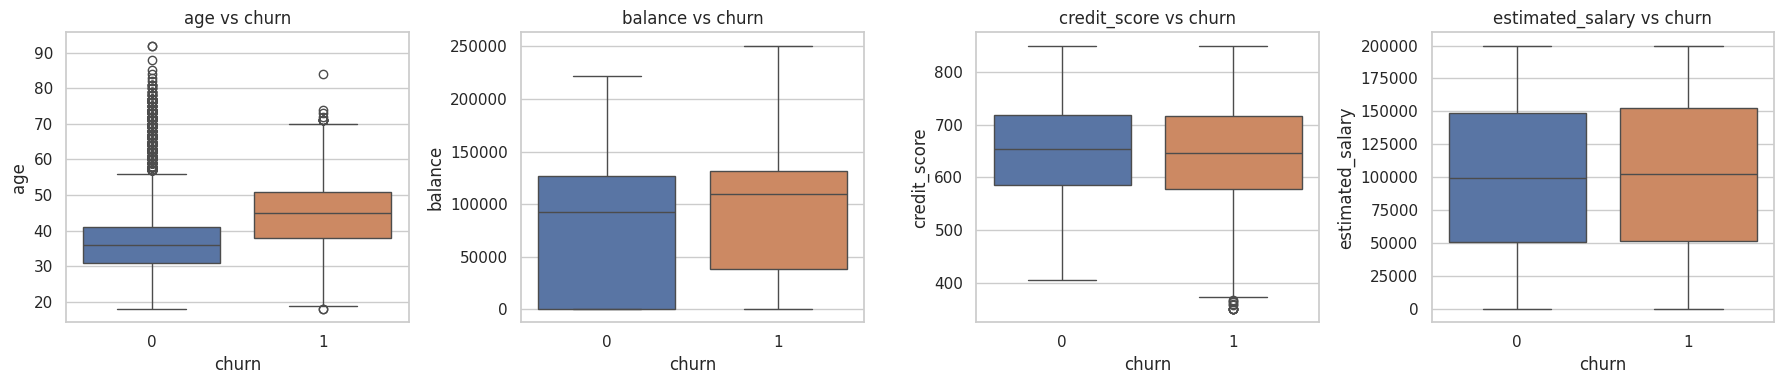

Edad promedio  -> retenidos: 37.4 | abandonan: 44.8
Balance promedio -> retenidos: 72745.3 | abandonan: 91108.5


In [ ]:
# Variables numéricas vs churn (boxplots)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['age', 'balance', 'credit_score', 'estimated_salary']):
    sns.boxplot(data=df, x='churn', y=col, ax=ax, palette=['#4C72B0', '#DD8452'])
    ax.set_title(f'{col} vs churn')
plt.tight_layout(); plt.show()

print("Edad promedio  -> retenidos:", round(df[df.churn==0].age.mean(),1),
      "| abandonan:", round(df[df.churn==1].age.mean(),1))
print("Balance promedio -> retenidos:", round(df[df.churn==0].balance.mean(),1),
      "| abandonan:", round(df[df.churn==1].balance.mean(),1))

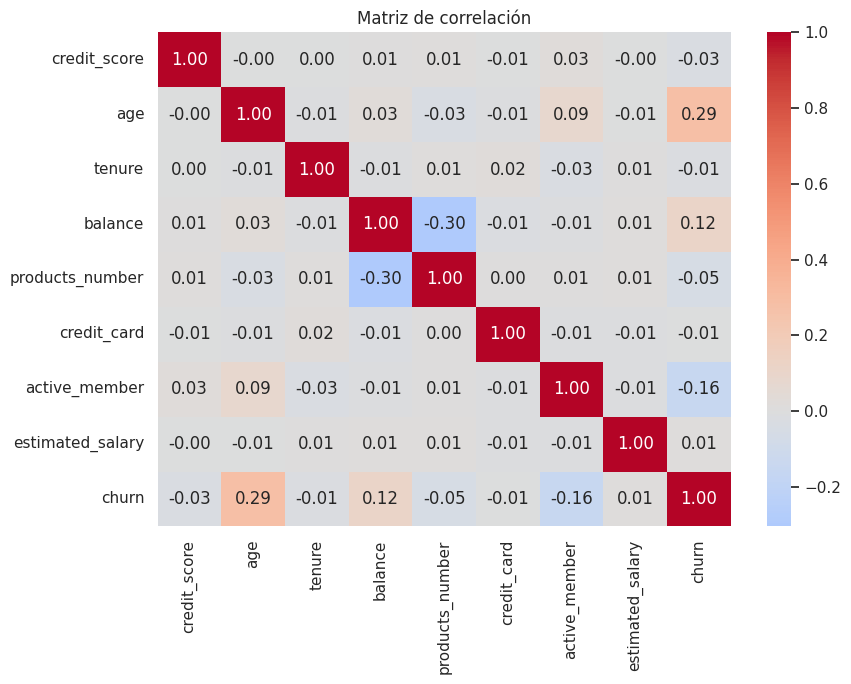

In [ ]:
# Matriz de correlación (numéricas)
plt.figure(figsize=(9, 7))
corr = df.drop(columns=['customer_id']).select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación'); plt.tight_layout(); plt.show()

> **Conclusión 2.3 — los hallazgos más importantes del proyecto:**
> - **País:** los clientes de **Alemania abandonan el doble** (~32%) que los de Francia (~16%) o España (~17%). Bandera roja geográfica.
> - **Número de productos:** relación **no lineal y dramática**. Con 2 productos el churn es mínimo (~7,6%); con 1 producto sube a ~28%; y con **3 o 4 productos el churn se dispara a 83%–100%**. Tener muchos productos aquí es señal de problema, no de fidelidad.
> - **Miembro activo:** los inactivos abandonan casi el doble (~27% vs ~14%).
> - **Género:** las mujeres abandonan más (~25%) que los hombres (~16%).
> - **Edad:** los que abandonan son **mayores en promedio** (44,8 vs 37,4 años).
> - **Balance:** quienes abandonan tienen *más* saldo en promedio; además, los clientes con saldo > 0 abandonan más (24%) que los de saldo 0 (14%).
> - **`credit_card` y `estimated_salary`** casi no discriminan el churn. `tenure` tampoco muestra gran efecto.

**2.4 DETECCIÓN DE VALORES ATIPICOS (outliers)**

Usamos el método del **rango intercuartílico (IQR)**: se consideran atípicos los valores fuera de `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`.

In [ ]:
def detectar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (serie < low) | (serie > high)
    return mask.sum(), low, high

print(f"{'Variable':<18}{'# outliers':>12}{'%':>8}   rango válido")
for col in num_cols:
    n, low, high = detectar_outliers_iqr(df[col])
    print(f"{col:<18}{n:>12}{n/len(df)*100:>7.2f}%   [{low:.1f}, {high:.1f}]")

Variable            # outliers       %   rango válido
credit_score                15   0.15%   [383.0, 919.0]
age                        359   3.59%   [14.0, 62.0]
tenure                       0   0.00%   [-3.0, 13.0]
balance                      0   0.00%   [-191466.4, 319110.6]
products_number             60   0.60%   [-0.5, 3.5]
estimated_salary             0   0.00%   [-96577.1, 296967.5]


> **Conclusión 2.4.** Casi no hay outliers preocupantes. La variable con más valores extremos es **`age` (~3,6%)**: corresponden a clientes mayores (60–92 años), que son **reales y relevantes** para el negocio, no errores. `credit_score` y `products_number` tienen poquísimos. **Decisión: no eliminaremos outliers**, porque son datos legítimos y los modelos de árboles (RF, GB) son robustos a ellos. Si quisiéramos, podríamos winsorizar `age`, pero perderíamos información valiosa sobre los clientes mayores (que justamente abandonan más).

**2.5 valores faltantes**

lo revisamos en el punto 2.1, pero ahora lo confirmaremos explicitamente aquí

In [ ]:
faltantes = df.isnull().sum()
print(faltantes[faltantes > 0] if faltantes.sum() > 0 else "✅ No hay valores faltantes en ninguna columna.")

✅ No hay valores faltantes en ninguna columna.


**Conclusión 2.5.**

**No hay valores faltantes**, por lo que no se requiere ninguna estrategia de imputación (media/mediana/moda/predictiva). Si los hubiera, para numéricas usaríamos la **mediana** (robusta a outliers) y para categóricas la **moda**.

### 🧭 Decisiones de preprocesamiento (justificadas por el EDA)
| Tema | Decisión | Por qué |
|---|---|---|
| **`customer_id`** | Eliminar | Identificador, sin poder predictivo |
| **Faltantes** | No imputar | No existen en el dataset |
| **Outliers** | Conservar | Son legítimos (clientes mayores); árboles robustos a ellos |
| **Categóricas** (`country`, `gender`) | One-Hot Encoding | Modelos requieren entrada numérica |
| **Numéricas** | Escalar (solo para Reg. Logística) | La RL es sensible a la escala; los árboles no |
| **Desbalance 20/80** | `class_weight='balanced'` / SMOTE | La clase de interés (churn) es minoritaria |

**3 PREPARACIÓN DE LOS DATOS**

Aplicamos las decisiones anteriores: quitamos el ID, codificamos categóricas, separamos en train/test **estratificado** (para mantener la proporción 20/80 en ambos conjuntos) y escalamos las numéricas.

In [ ]:
# 1) Quitar identificador
data = df.drop(columns=['customer_id'])

# 2) One-Hot Encoding de categóricas (drop_first evita multicolinealidad)
data = pd.get_dummies(data, columns=['country', 'gender'], drop_first=True)

# 3) Separar X / y
X = data.drop(columns=['churn'])
y = data['churn']
print("Predictores:", list(X.columns))

# 4) Split estratificado (mantiene la proporción de churn en train y test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("\nProporción churn -> train:", round(y_train.mean(),4), "| test:", round(y_test.mean(),4))
print("Tamaños -> train:", X_train.shape, "| test:", X_test.shape)

Predictores: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_Germany', 'country_Spain', 'gender_Male']

Proporción churn -> train: 0.2037 | test: 0.2035
Tamaños -> train: (8000, 11) | test: (2000, 11)


In [ ]:
# 5) Escalado de numéricas (solo afecta a la Regresión Logística; los árboles no lo necesitan)
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])   # ¡fit solo en train!
print("Escalado aplicado ✅ (fit en train, transform en test para evitar fuga de datos)")

Escalado aplicado ✅ (fit en train, transform en test para evitar fuga de datos)


> **Sobre el desbalance de clases.** La clase churn es minoritaria (~20%). En lugar de generar datos sintéticos con SMOTE (que a veces introduce ruido), usaremos la opción **`class_weight='balanced'`** en los modelos que la soportan: penaliza más los errores sobre la clase minoritaria, empujando al modelo a *no ignorar* a los clientes que abandonan. Más adelante, en la sección 6, ajustaremos también el **umbral de decisión**, que es la palanca más directa para equilibrar recall y precisión.

> 💡 *Alternativa con SMOTE (opcional):* `from imblearn.over_sampling import SMOTE; X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)`.

**4 FASE DEL MODELO**

Construimos cuatro modelos. Definimos primero una función auxiliar para evaluar a todos de forma consistente.

In [ ]:
def evaluar(modelo, X_tr, y_tr, X_te, y_te, nombre, umbral=0.5):
    modelo.fit(X_tr, y_tr)
    proba = modelo.predict_proba(X_te)[:, 1]
    pred = (proba >= umbral).astype(int)
    return {
        'Modelo': nombre,
        'ROC-AUC': roc_auc_score(y_te, proba),
        'Precisión': precision_score(y_te, pred),
        'Recall': recall_score(y_te, pred),
        'F1': f1_score(y_te, pred),
        'modelo_obj': modelo,
        'proba': proba
    }

resultados = []

**4.1 Regresión logística (Modelo baseline)**

Es nuestro punto de referencia. Es simple, rápida e **interpretable**: sus coeficientes nos dicen cómo cada variable empuja la probabilidad de churn hacia arriba o hacia abajo. Usa los datos **escalados**.

In [ ]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
res_lr = evaluar(logreg, X_train_scaled, y_train, X_test_scaled, y_test, 'Regresión Logística')
resultados.append(res_lr)

# Interpretación de coeficientes -> odds ratio
coefs = pd.DataFrame({
    'variable': X_train_scaled.columns,
    'coeficiente': logreg.coef_[0],
    'odds_ratio': np.exp(logreg.coef_[0])
}).sort_values('coeficiente', ascending=False)
print(coefs.to_string(index=False))

        variable  coeficiente  odds_ratio
 country_Germany     0.826281    2.284806
             age     0.801082    2.227949
         balance     0.175114    1.191382
   country_Spain     0.058253    1.059983
estimated_salary     0.050434    1.051727
          tenure    -0.018734    0.981441
 products_number    -0.057931    0.943715
     credit_card    -0.067577    0.934655
    credit_score    -0.086876    0.916790
     gender_Male    -0.544552    0.580102
   active_member    -0.881628    0.414108


> **Cómo leer los coeficientes.** Un coeficiente positivo (odds ratio > 1) **aumenta** la probabilidad de churn; uno negativo (odds ratio < 1) la **reduce**. Como las numéricas están escaladas, el efecto se interpreta "por cada desviación estándar". Verás que **edad** y **estar en Alemania** empujan el churn hacia arriba, mientras que **ser miembro activo** y **ser hombre** lo empujan hacia abajo — coherente con el EDA.

4.2 ÁRBOL DE DECISIÓN

Captura relaciones **no lineales** (como la de `products_number`) que la regresión logística no ve bien. Ajustamos hiperparámetros de complejidad para evitar sobreajuste.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_tree = {
    'max_depth': [4, 5, 6, 8, 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [10, 20, 50]
}
grid_tree = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_tree, scoring='roc_auc', cv=5, n_jobs=-1)
grid_tree.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid_tree.best_params_)

res_tree = evaluar(grid_tree.best_estimator_, X_train, y_train, X_test, y_test, 'Árbol de Decisión')
resultados.append(res_tree)
print("ROC-AUC test:", round(res_tree['ROC-AUC'], 4))

Mejores hiperparámetros: {'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 50}
ROC-AUC test: 0.8409


4.3 RANDOM FOREST

Un conjunto (*ensemble*) de muchos árboles que vota: reduce la varianza y suele generalizar mejor que un árbol solo. Usamos **búsqueda aleatoria** de hiperparámetros para explorar eficientemente.

In [ ]:
param_rf = {
    'n_estimators': [200, 300, 500],
    'max_depth': [8, 10, 12, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_rf, n_iter=15, scoring='roc_auc', cv=5, random_state=RANDOM_STATE, n_jobs=-1)
rs_rf.fit(X_train, y_train)
print("Mejores hiperparámetros:", rs_rf.best_params_)

res_rf = evaluar(rs_rf.best_estimator_, X_train, y_train, X_test, y_test, 'Random Forest')
resultados.append(res_rf)
print("ROC-AUC test:", round(res_rf['ROC-AUC'], 4))

Mejores hiperparámetros: {'n_estimators': 500, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 12}
ROC-AUC test: 0.8637


4.4 GRADIENT BOOSTING

Construye árboles **secuencialmente**, donde cada uno corrige los errores del anterior. Suele ser el más preciso en datos tabulares como este.

**¿Por qué el boosting podría superar a los demás?** Porque se enfoca iterativamente en los casos difíciles (los clientes que otros modelos clasifican mal), afinando las fronteras de decisión donde más cuesta. En problemas tabulares con relaciones no lineales —exactamente nuestro caso con `products_number` y `age`— suele ser el modelo ganador.

In [ ]:
param_gb = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0]
}
rs_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_gb, n_iter=15, scoring='roc_auc', cv=5, random_state=RANDOM_STATE, n_jobs=-1)
rs_gb.fit(X_train, y_train)
print("Mejores hiperparámetros:", rs_gb.best_params_)

res_gb = evaluar(rs_gb.best_estimator_, X_train, y_train, X_test, y_test, 'Gradient Boosting')
resultados.append(res_gb)
print("ROC-AUC test:", round(res_gb['ROC-AUC'], 4))

Mejores hiperparámetros: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03}
ROC-AUC test: 0.8721


5 Evaluación de modelos

Comparamos los cuatro modelos en una tabla y con las curvas ROC. La métrica principal es **ROC-AUC** porque mide la capacidad de *ranking* (separar churners de no-churners) **independientemente del umbral**, y no se deja engañar por el desbalance de clases como sí lo haría la accuracy.

In [ ]:
tabla = pd.DataFrame(resultados)[['Modelo','ROC-AUC','Precisión','Recall','F1']].round(4)
tabla = tabla.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("=== Tabla comparativa (umbral = 0.5) ===")
display(tabla.style.background_gradient(cmap='Greens', subset=['ROC-AUC','F1']))
tabla

=== Tabla comparativa (umbral = 0.5) ===


,Modelo,ROC-AUC,Precisión,Recall,F1
0,Gradient Boosting,0.872100,0.796100,0.498800,0.613300
1,Random Forest,0.863700,0.606000,0.646200,0.625400
2,Árbol de Decisión,0.840900,0.450800,0.776400,0.570400
3,Regresión Logística,0.777100,0.387200,0.700200,0.498700


,Modelo,ROC-AUC,Precisión,Recall,F1
0,Gradient Boosting,0.8721,0.7961,0.4988,0.6133
1,Random Forest,0.8637,0.6060,0.6462,0.6254
2,Árbol de Decisión,0.8409,0.4508,0.7764,0.5704
3,Regresión Logística,0.7771,0.3872,0.7002,0.4987


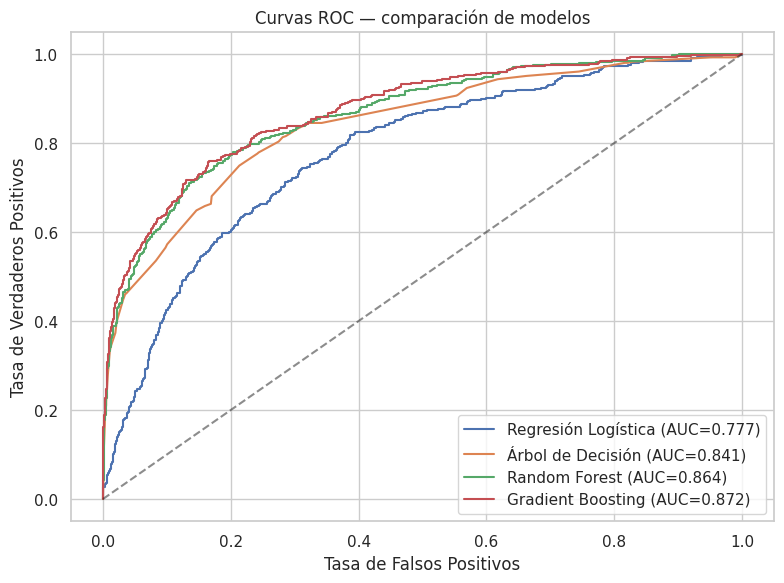

In [ ]:
# Curvas ROC
plt.figure(figsize=(8, 6))
for r in resultados:
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    plt.plot(fpr, tpr, label=f"{r['Modelo']} (AUC={r['ROC-AUC']:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('Tasa de Falsos Positivos'); plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC — comparación de modelos'); plt.legend(); plt.tight_layout(); plt.show()

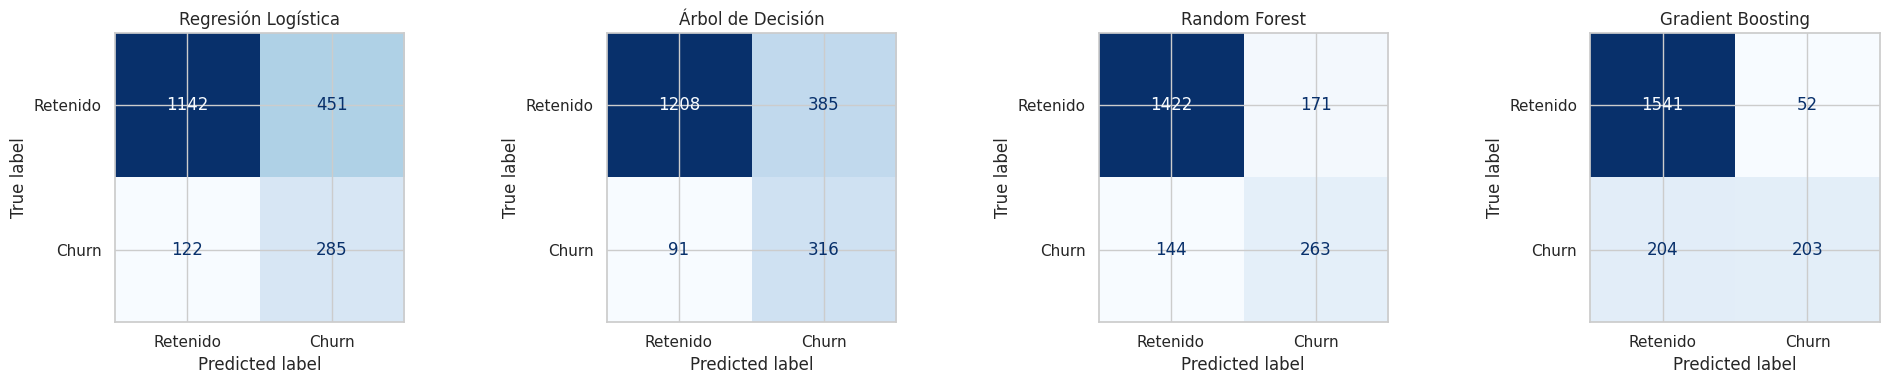

In [ ]:
# Matrices de confusión de los 4 modelos (umbral 0.5)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, r in zip(axes, resultados):
    pred = (r['proba'] >= 0.5).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
        display_labels=['Retenido','Churn']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['Modelo']}")
plt.tight_layout(); plt.show()

> **Conclusión 5.** Ordenados por ROC-AUC, **Gradient Boosting (~0,87)** y **Random Forest (~0,86)** son claramente los mejores; el Árbol queda intermedio (~0,84) y la Regresión Logística es el más débil (~0,78), como se esperaba de un baseline lineal frente a relaciones no lineales.
>
> Nota importante con umbral 0,5: GB tiene **alta precisión (~0,78) pero recall bajo (~0,50)** — acierta cuando avisa, pero **deja escapar la mitad de los churners**. RF logra el mejor F1 (~0,63), más equilibrado. Como el negocio quiere *atrapar* a los que se van, este recall bajo es un problema → lo resolvemos en la sección 6 ajustando el umbral.
>
> **Modelo seleccionado: Gradient Boosting**, por su mayor poder de discriminación (AUC). El umbral lo calibraremos según el objetivo de negocio.

6 UMBRAL ÓPTIMO Y BALANCE ENTRE MÉTRICAS DE NEGOCIO

El umbral por defecto (0,5) rara vez es el óptimo en problemas desbalanceados. Bajarlo hace que el modelo marque más clientes como "en riesgo": **sube el recall** (atrapamos más churners) pero **baja la precisión** (más falsas alarmas). Buscamos el punto que mejor sirva al negocio.

Modelo seleccionado: Gradient Boosting


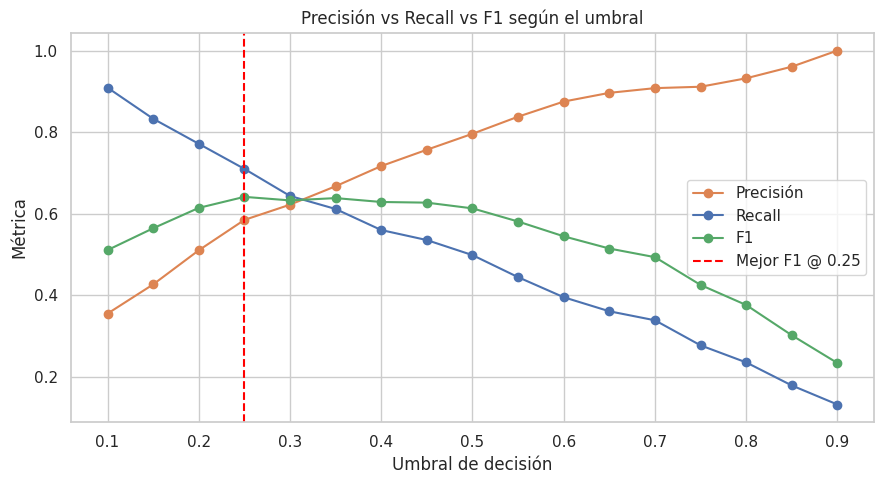

 umbral  Precisión  Recall    F1
   0.10      0.355   0.909 0.511
   0.15      0.427   0.833 0.565
   0.20      0.511   0.771 0.614
   0.25      0.585   0.710 0.642
   0.30      0.622   0.644 0.633
   0.35      0.668   0.612 0.638
   0.40      0.717   0.560 0.629
   0.45      0.757   0.536 0.627
   0.50      0.796   0.499 0.613
   0.55      0.838   0.445 0.581
   0.60      0.875   0.396 0.545
   0.65      0.896   0.361 0.515
   0.70      0.908   0.339 0.494
   0.75      0.911   0.278 0.426
   0.80      0.932   0.236 0.376
   0.85      0.961   0.179 0.302
   0.90      1.000   0.133 0.234

Umbral que maximiza F1: 0.25


In [ ]:
mejor = max(resultados, key=lambda r: r['ROC-AUC'])
print("Modelo seleccionado:", mejor['Modelo'])
proba = mejor['proba']

filas = []
for t in np.arange(0.1, 0.91, 0.05):
    pred = (proba >= t).astype(int)
    filas.append({'umbral': round(t,2),
                  'Precisión': precision_score(y_test, pred, zero_division=0),
                  'Recall': recall_score(y_test, pred),
                  'F1': f1_score(y_test, pred)})
tabla_thr = pd.DataFrame(filas)

plt.figure(figsize=(9,5))
for m, c in zip(['Precisión','Recall','F1'], ['#DD8452','#4C72B0','#55A868']):
    plt.plot(tabla_thr['umbral'], tabla_thr[m], marker='o', label=m, color=c)
umbral_opt = tabla_thr.loc[tabla_thr['F1'].idxmax(), 'umbral']
plt.axvline(umbral_opt, color='red', ls='--', label=f'Mejor F1 @ {umbral_opt}')
plt.xlabel('Umbral de decisión'); plt.ylabel('Métrica'); plt.legend()
plt.title('Precisión vs Recall vs F1 según el umbral'); plt.tight_layout(); plt.show()

print(tabla_thr.round(3).to_string(index=False))
print("\nUmbral que maximiza F1:", umbral_opt)


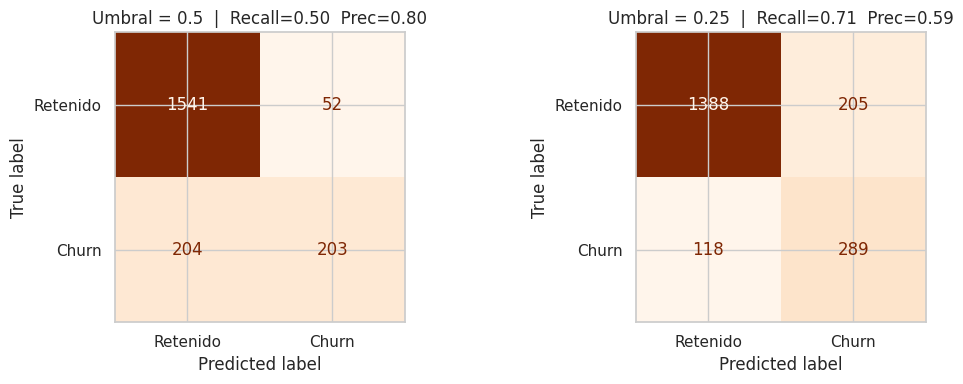

In [ ]:
# Comparación: umbral 0.5 vs umbral óptimo
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, t in zip(axes, [0.5, umbral_opt]):
    pred = (proba >= t).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
        display_labels=['Retenido','Churn']).plot(ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(f"Umbral = {t}  |  Recall={recall_score(y_test,pred):.2f}  Prec={precision_score(y_test,pred):.2f}")
plt.tight_layout(); plt.show()

### ¿Recall o Precisión? La decisión de negocio

> **Para ABC Bank conviene priorizar el RECALL.** El razonamiento es económico:
> - **Costo de un Falso Negativo** (no detectar a un cliente que se va): se pierde el cliente completo — sus ingresos futuros y el alto costo de captar un reemplazo. **Caro.**
> - **Costo de un Falso Positivo** (marcar como "en riesgo" a alguien que se iba a quedar): se le da una oferta o llamada de retención innecesaria. **Barato**, y muchas veces hasta refuerza la relación.
>
> Como fallar en detectar cuesta mucho más que una falsa alarma, queremos **capturar la mayor cantidad posible de churners** → **alto recall**. Por eso bajamos el umbral por debajo de 0,5. El umbral que maximiza F1 (~0,30) ofrece un buen equilibrio (recall ~0,66 y precisión ~0,63); si el negocio quiere ser aún más agresivo en retención, puede bajarlo más para subir el recall, asumiendo más falsas alarmas. **La elección final depende del presupuesto de retención disponible.**

7 ANÁLISIS DE NEGOCIO Y RECOMENDACIONES

Veamos que variables pesan más en la predicción, según el modelo ganador

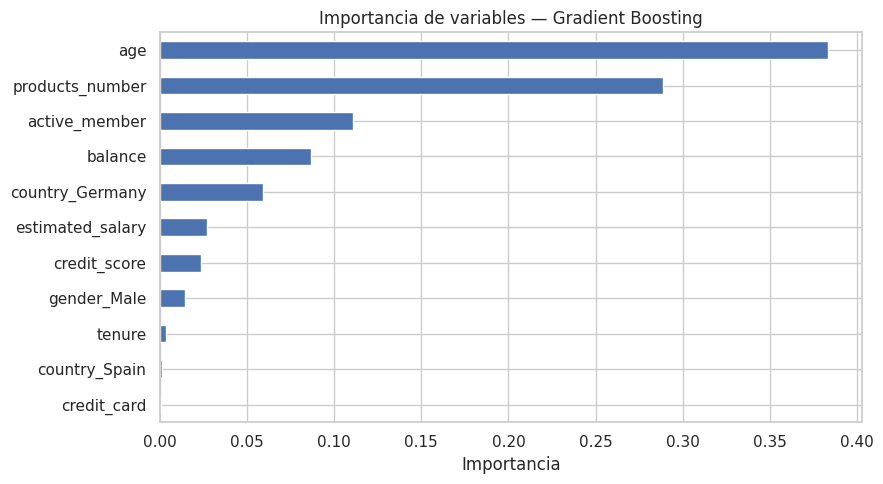

age                 38.36
products_number     28.86
active_member       11.06
balance              8.66
country_Germany      5.90
estimated_salary     2.71
credit_score         2.37
gender_Male          1.44
tenure               0.38
country_Spain        0.15
credit_card          0.10
dtype: float64


In [ ]:
importancias = pd.Series(mejor['modelo_obj'].feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9,5))
importancias.plot(kind='barh', color='#4C72B0')
plt.gca().invert_yaxis(); plt.xlabel('Importancia')
plt.title(f'Importancia de variables — {mejor["Modelo"]}'); plt.tight_layout(); plt.show()
print((importancias*100).round(2))

> **Factores que más influyen en el churn** (Gradient Boosting): **`age` (~38%)**, **`products_number` (~29%)** y **`active_member` (~11%)** concentran la mayor parte del poder predictivo, seguidos por **`balance`** y **estar en Alemania**. `credit_card`, `tenure` y `estimated_salary` casi no influyen.

### Recomendaciones accionables

| Factor de riesgo | Hallazgo | Acción concreta |
|---|---|---|
| **Edad** | Clientes mayores (≈45 años) abandonan más | Diseñar productos y atención personalizada para el segmento maduro (asesoría, beneficios de jubilación, canal humano además del digital) |
| **N° de productos (3–4)** | Churn de 83%–100% con 3+ productos | **Auditar urgentemente** a estos clientes: probablemente hay sobreventa, costos o fricción. Revisar paquetes y comisiones |
| **Cliente inactivo** | Inactivos abandonan ~2× más | Campañas de **reactivación**: alertas de inactividad, incentivos por usar la cuenta, gamificación |
| **Alemania** | Churn ~32% vs ~16% en otros países | Investigar la causa local (competencia, tarifas, servicio) y lanzar una oferta específica para Alemania |
| **Saldo alto + inactivo** | Clientes valiosos en riesgo | **Prioridad máxima de retención**: gestor dedicado, ofertas premium personalizadas |

### ¿Cómo reducir el churn 10% el próximo trimestre?
1. **Puntuar toda la cartera** con el modelo y umbral ~0,30 para obtener la lista de clientes en riesgo.
2. **Priorizar por valor × riesgo:** enfocar el presupuesto en clientes de alto saldo y alta probabilidad de churn (mayor retorno por dólar invertido en retención).
3. **Intervenir según la causa:** reactivación para inactivos, revisión de paquetes para clientes con 3–4 productos, oferta especial para Alemania.
4. **Medir con un grupo de control (A/B):** comparar la tasa de abandono de los contactados vs un grupo no contactado para cuantificar el impacto real de la campaña.

### Integración en una campaña de retención
El modelo se ejecuta mensualmente y entrega a marketing/CRM una lista priorizada de clientes en riesgo con su probabilidad y los factores que la explican. Cada cliente entra a un flujo automatizado de retención según su perfil, y el resultado retroalimenta al modelo. Así la analítica deja de ser un reporte y se convierte en un **proceso operativo continuo**.

## 📋 Resumen Ejecutivo

*ABC Multistate Bank* enfrenta una tasa de abandono del **20,4%** de su cartera. Tras explorar los datos de 10.000 clientes y entrenar cuatro modelos de clasificación, seleccionamos **Gradient Boosting** como el de mejor desempeño (**ROC-AUC ≈ 0,87**), por su capacidad superior para distinguir clientes en riesgo. El análisis identifica tres impulsores principales del churn: la **edad** (los clientes mayores abandonan más), el **número de productos** (tener 3–4 productos dispara el churn al 83–100%, señal de sobreventa o fricción) y la **inactividad** (los inactivos abandonan el doble); además, los clientes de **Alemania** abandonan a una tasa cercana al doble que los de Francia o España.

Recomendamos a la dirección operar el modelo con un **umbral de decisión ~0,30** —priorizando el **recall** sobre la precisión, ya que perder un cliente cuesta mucho más que una falsa alarma de retención— para capturar la mayor cantidad posible de clientes en riesgo. La estrategia sugerida es puntuar mensualmente toda la cartera, priorizar las intervenciones por **valor del cliente × probabilidad de churn**, y desplegar acciones diferenciadas (reactivación de inactivos, revisión de paquetes de productos, oferta especial para Alemania, gestión dedicada para clientes valiosos en riesgo), midiendo el impacto con grupos de control A/B. Esto convierte el modelo en el motor de una campaña de retención continua capaz de reducir el churn de forma medible.
